In [1]:
# Run this setup only in Google Colab
import os
import subprocess
import sys

try:
    from google.colab import drive
    drive.mount("/content/drive")
    os.chdir("/content/drive/MyDrive/Colab Notebooks/ml2_trabalhos_2026")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", ".", "--no-deps"])
except ModuleNotFoundError:
    print("Not running in Colab; skipping Drive mount and install steps.")

Not running in Colab; skipping Drive mount and install steps.


In [2]:
import random
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torchvision

import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
import matplotlib.pyplot as plt

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Semente: {seed}")
print(f"Dispositivo: {device}")
print("Versão do Torch:", torch.__version__)
print("Versão do Torchvision:", torchvision.__version__)

student_run_tag = "BZA_19_05_2026"
output_dir = Path("finalProject_outputs")
output_dir.mkdir(exist_ok=True)
(output_dir / student_run_tag).mkdir(exist_ok=True)
print("Diretório de saída:", output_dir / student_run_tag)

Semente: 42
Dispositivo: cuda
Versão do Torch: 2.11.0+cu128
Versão do Torchvision: 0.26.0+cu128
Diretório de saída: finalProject_outputs/BZA_19_05_2026


In [4]:
from isic2018_dataset import download_isic2018, get_dataloaders

IMAGE_SIZE = 224
BATCH_SIZE = 32

download_isic2018(root="./data/isic2018")
train_loader, val_loader, test_loader = get_dataloaders(
    root="./data/isic2018",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)


  Split: TRAIN
  Baixando https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task3_Training_Input.zip …


  Extraindo train_images.zip → data/isic2018/_cache/train_images_extracted …
  Movendo imagens → data/isic2018/train/images
  Baixando https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task3_Training_GroundTruth.zip …


  Extraindo train_gt.zip → data/isic2018/_cache/train_gt_extracted …
  Copiando ground truth → data/isic2018/train/ground_truth.csv
  Baixando https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task3_Training_LesionGroupings.csv …



  Split: VAL
  Baixando https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task3_Validation_Input.zip …


  Extraindo val_images.zip → data/isic2018/_cache/val_images_extracted …
  Movendo imagens → data/isic2018/val/images
  Baixando https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task3_Validation_GroundTruth.zip …


  Extraindo val_gt.zip → data/isic2018/_cache/val_gt_extracted …
  Copiando ground truth → data/isic2018/val/ground_truth.csv

  Split: TEST
  Baixando https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task3_Test_Input.zip …


  Extraindo test_images.zip → data/isic2018/_cache/test_images_extracted …
  Movendo imagens → data/isic2018/test/images
  Baixando https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task3_Test_GroundTruth.zip …


  Extraindo test_gt.zip → data/isic2018/_cache/test_gt_extracted …
  Copiando ground truth → data/isic2018/test/ground_truth.csv

✓ Download concluído. Dados em: /mnt/storage_C1/bianca_zavadisk/ml2/fine-grained-ml2/data/isic2018


In [5]:
print(f'Conjunto de treino: {len(train_loader.dataset)} imagens')
print(f'Conjunto de validação: {len(val_loader.dataset)} imagens')
print(f'Conjunto de teste: {len(test_loader.dataset)} imagens')

Conjunto de treino: 10015 imagens
Conjunto de validação: 193 imagens
Conjunto de teste: 1512 imagens


In [9]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader, ConcatDataset

dataset = ConcatDataset([train_loader.dataset, val_loader.dataset])

labels = []
for ds in dataset.datasets:
    if hasattr(ds, "targets"):
        labels.extend(list(ds.targets))
    elif hasattr(ds, "labels"):
        labels.extend(list(ds.labels))
    else:
        # fallback (pode ser caro pois itera o dataset)
        labels.extend([lbl for _, lbl in ds])

# Stratified split no dataset concatenado
train_idx, val_idx = train_test_split(
    list(range(len(dataset))),
    test_size=0.15,
    stratify=labels,
    random_state=seed,
)

train_subset = Subset(dataset, train_idx)
val_subset = Subset(dataset, val_idx)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

In [14]:
print(f'Conjunto de treino: {len(train_loader.dataset)} imagens')
print(f'Conjunto de validação: {len(val_loader.dataset)} imagens')
print(f'Conjunto de teste: {len(test_loader.dataset)} imagens')

Conjunto de treino: 8676 imagens
Conjunto de validação: 1532 imagens
Conjunto de teste: 1512 imagens


In [10]:
images, labels = next(iter(train_loader))

print("Shape de image (após resize):", images.shape)
print("Shape dos labels:", labels.shape)
print("dtype de images:", images.dtype)
print("dtype de labels:", labels.dtype)
print("Primeiros labels:", labels[:10])

Shape de image (após resize): torch.Size([32, 3, 224, 224])
Shape dos labels: torch.Size([32])
dtype de images: torch.float32
dtype de labels: torch.int64
Primeiros labels: tensor([1, 1, 0, 1, 0, 0, 0, 2, 1, 0])


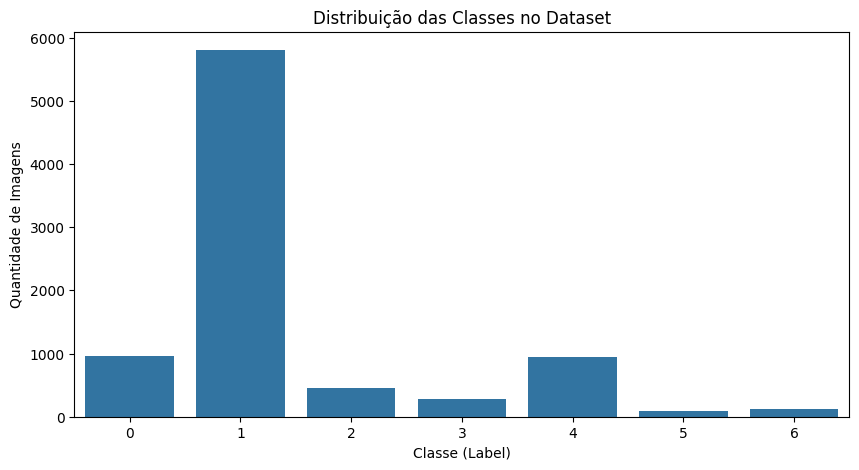

In [11]:
# Análise das classes
import seaborn as sns
from collections import Counter

#Extrai todas as labels
all_labels = [label for _, label in train_loader.dataset]
counts = Counter(all_labels)

plt.figure(figsize=(10, 5))
sns.barplot(x=list(counts.keys()), y=list(counts.values()))
plt.title("Distribuição das Classes no Dataset")
plt.xlabel("Classe (Label)")
plt.ylabel("Quantidade de Imagens")
plt.show()

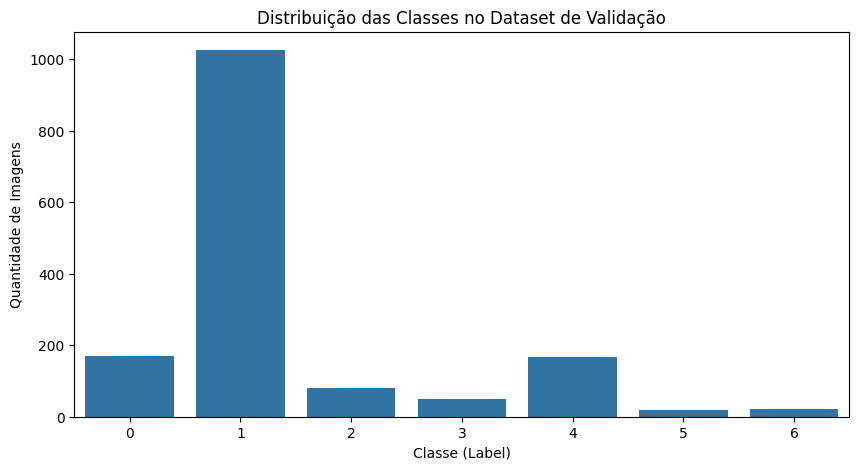

In [ ]:
all_labels = [label for _, label in val_loader.dataset]
counts = Counter(all_labels)

plt.figure(figsize=(10, 5))
sns.barplot(x=list(counts.keys()), y=list(counts.values()))
plt.title("Distribuição das Classes no Dataset de Validação")
plt.xlabel("Classe (Label)")
plt.ylabel("Quantidade de Imagens")
plt.show()

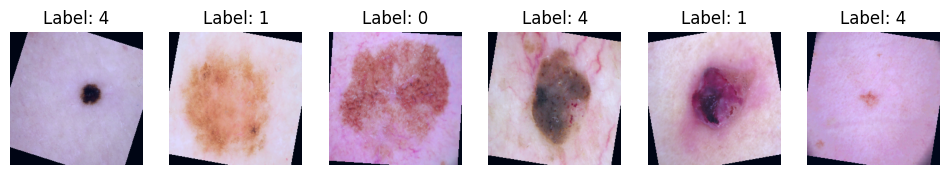

In [21]:
import torchvision

# Exibe algumas imagens
dataiter = iter(train_loader)

# função next() para pegar o primeiro batch
images, labels = next(dataiter)

fig, axes = plt.subplots(1, 6, figsize=(12, 2))

for i in range(6):
    img = images[i].permute(1, 2, 0) # Transforma de (C, H, W) para (H, W, C)

    # Normaliza a imagem para o range [0, 1] para exibição
    # Isso é importante porque muitas transformações em PyTorch normalizam as imagens
    # para um range diferente (e.g., média 0, desvio padrão 1).
    img = img - img.min()
    img = img / img.max()

    axes[i].imshow(img)
    axes[i].set_title(f'Label: {labels[i].item()}')
    axes[i].axis('off')

plt.show()